In [1]:
import numpy as np
import ase
import pyscf
import equiv_dens.utils.base as utils

Use "numpy" for Fourier Transform


In [2]:
calc  = dict(np.load('/home/mihail/Downloads/traj.out.DFT.pbe.def2svp.GeometryIdx-3.npz'))
print(calc)

{'type': array('d', dtype='<U1'), 'R': array([[13.2 , 12.63, 12.74],
       [12.67, 12.66, 13.7 ],
       [13.16, 11.65, 12.28],
       [14.21, 13.03, 12.85],
       [12.4 , 13.56, 11.83],
       [11.89, 13.1 , 10.82],
       [12.25, 14.81, 12.28],
       [12.74, 15.06, 13.13],
       [11.56, 15.93, 11.67],
       [10.52, 15.7 , 11.47],
       [11.57, 17.13, 12.62],
       [10.83, 17.02, 13.42],
       [12.54, 17.26, 13.11],
       [11.25, 18.09, 12.22],
       [12.1 , 16.25, 10.29],
       [13.09, 16.97, 10.14],
       [11.59, 15.71,  9.18],
       [10.82, 15.06,  9.22],
       [12.13, 16.05,  7.88],
       [13.01, 15.41,  7.79],
       [11.43, 15.73,  7.1 ],
       [12.35, 17.09,  7.66]]), 'z': array([6, 1, 1, 1, 6, 8, 7, 1, 6, 1, 6, 1, 1, 1, 6, 8, 7, 1, 6, 1, 1, 1]), 'E': array(-494871.60427389), 'F': array([[-21.44320785,  43.57956992,  -2.6047709 ],
       [  4.79490643, -12.34425505,  20.14611615],
       [  6.73370378, -23.26538167,  -3.82548608],
       [ 22.36336121,  -4.30620

In [5]:
from pyscf import gto
import pyscf
print(pyscf.__version__)
calc_npy = {}

calc_npy['positions'] = calc['R'][None, :]
calc_npy['atom_types'] = utils.numbers_to_symbols(calc['z'])
calc_npy['atom_numbers'] = calc['z']
calc_npy['energy'] = calc['E']
calc_npy['forces'] = calc['F']

calc_pyscf = []
pyscf_atoms = [(calc_npy['atom_types'][i], calc_npy['positions'][0, i, :]) for i in range(len(calc['z']))]
mols = []
mol = (gto.Mole(atom=pyscf_atoms, basis='6311g**'))
mol_dict = mol.pack()
calc_dict = {'mo_coeff': calc['mo_coeff'], 'mo_occ': calc['mo_occ']}
print('mo_coeff shape', calc['mo_coeff'].shape)
print('mo_occ shape', calc['mo_occ'].shape)
calc_pyscf = [(mol_dict, calc_dict)]

np.save('datasets/huziel_def2svp_test_pyscf.npy', calc_pyscf, allow_pickle=True)

np.save('datasets/huziel_def2svp_test.npy', calc_npy, allow_pickle=True)


1.7.4
mo_coeff shape (200, 200)
mo_occ shape (200,)


In [13]:
from equiv_dens.data.density_dataset import AtomsDensityData
from functools import partial
from equiv_dens.utils.grids import cubical_grid, cubical_sampling, CubicalGrid
import torch

cube_grid_fn = partial(cubical_grid, nx=50, ny=50, nz=50,
                       extent=np.array([20, 20, 20]),
                       origin=np.array([5, 5 , 5]))
cube_sampling_fn = cubical_sampling

dataset = AtomsDensityData(np_path='datasets/huziel_def2svp_test.npy', density_path='datasets/huziel_def2svp_test_pyscf.npy',
                                      orbitals_path='datasets/augccpvqzjkfit_orbital_basis_df.npy',
                                      density_n_samp=10000000000,
                                      required_properties=['density'],
                                      center_positions=False,
                                      radial_coeffs_file='datasets/augccpvqzjkfit_radial_coeffs_df.npy',
                                      dtype=torch.float,
                                      grid_fn=cube_grid_fn,
                                      sampling_fn=cube_sampling_fn)

Starting atomsdata density init
Some variables
atoms keys dict_keys(['positions', 'atom_types', 'atom_numbers', 'energy', 'forces'])
mol_dict [('C', array([13.2 , 12.63, 12.74])), ('H', array([12.67, 12.66, 13.7 ])), ('H', array([13.16, 11.65, 12.28])), ('H', array([14.21, 13.03, 12.85])), ('C', array([12.4 , 13.56, 11.83])), ('O', array([11.89, 13.1 , 10.82])), ('N', array([12.25, 14.81, 12.28])), ('H', array([12.74, 15.06, 13.13])), ('C', array([11.56, 15.93, 11.67])), ('H', array([10.52, 15.7 , 11.47])), ('C', array([11.57, 17.13, 12.62])), ('H', array([10.83, 17.02, 13.42])), ('H', array([12.54, 17.26, 13.11])), ('H', array([11.25, 18.09, 12.22])), ('C', array([12.1 , 16.25, 10.29])), ('O', array([13.09, 16.97, 10.14])), ('N', array([11.59, 15.71,  9.18])), ('H', array([10.82, 15.06,  9.22])), ('C', array([12.13, 16.05,  7.88])), ('H', array([13.01, 15.41,  7.79])), ('H', array([11.43, 15.73,  7.1 ])), ('H', array([12.35, 17.09,  7.66]))]
finished init


In [14]:
from pyscf.dft import numint
from pyscf.lib import param

mol.build()
print('atoms', mol.atom)
grid_spec = cube_grid_fn(calc_npy)
grid_coords, coord_weights = cube_sampling_fn(grid_spec, 100000000, calc_npy['atom_types'], calc_npy['positions'][[0]])
print('grid_coords', grid_coords.shape)
scaled_grid_coords = grid_coords / param.BOHR
print('scaled grid_coords', scaled_grid_coords.shape)


print('mol_dict', mol.pack())

atoms [('C', array([13.2 , 12.63, 12.74])), ('H', array([12.67, 12.66, 13.7 ])), ('H', array([13.16, 11.65, 12.28])), ('H', array([14.21, 13.03, 12.85])), ('C', array([12.4 , 13.56, 11.83])), ('O', array([11.89, 13.1 , 10.82])), ('N', array([12.25, 14.81, 12.28])), ('H', array([12.74, 15.06, 13.13])), ('C', array([11.56, 15.93, 11.67])), ('H', array([10.52, 15.7 , 11.47])), ('C', array([11.57, 17.13, 12.62])), ('H', array([10.83, 17.02, 13.42])), ('H', array([12.54, 17.26, 13.11])), ('H', array([11.25, 18.09, 12.22])), ('C', array([12.1 , 16.25, 10.29])), ('O', array([13.09, 16.97, 10.14])), ('N', array([11.59, 15.71,  9.18])), ('H', array([10.82, 15.06,  9.22])), ('C', array([12.13, 16.05,  7.88])), ('H', array([13.01, 15.41,  7.79])), ('H', array([11.43, 15.73,  7.1 ])), ('H', array([12.35, 17.09,  7.66]))]
mol_dict [('C', array([13.2 , 12.63, 12.74])), ('H', array([12.67, 12.66, 13.7 ])), ('H', array([13.16, 11.65, 12.28])), ('H', array([14.21, 13.03, 12.85])), ('C', array([12.4 , 1

In [15]:
ao = numint.eval_ao(mol, scaled_grid_coords[0])
print('ao shape', ao.shape)

rho = numint.eval_rho2(mol, ao, **calc_dict)
print('rho shape', rho.shape)

ao shape (125000, 200)
rho shape (125000,)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
preparing sample
loadded sample


<IPython.core.display.Javascript object>


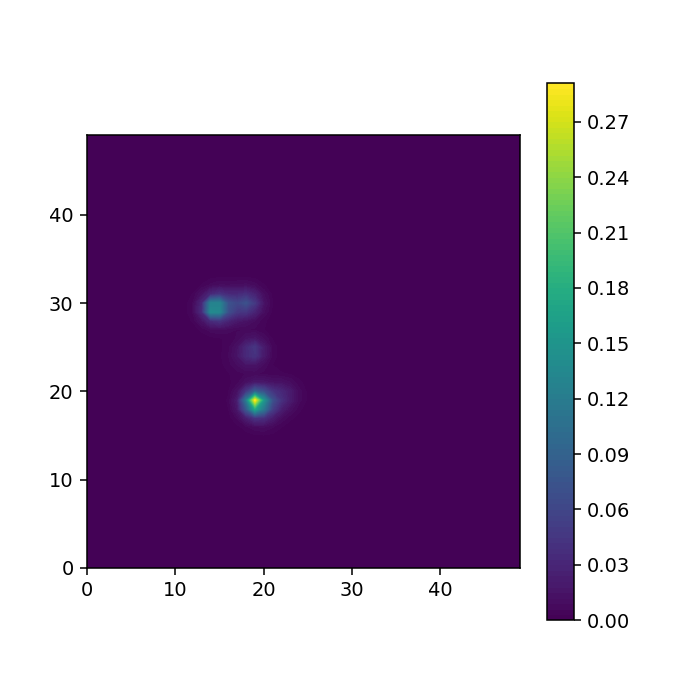

idx [    21   2521   5021 ... 119971 122471 124971]
pos tensor([[[13.2000, 12.6300, 12.7400],
         [12.6700, 12.6600, 13.7000],
         [13.1600, 11.6500, 12.2800],
         [14.2100, 13.0300, 12.8500],
         [12.4000, 13.5600, 11.8300],
         [11.8900, 13.1000, 10.8200],
         [12.2500, 14.8100, 12.2800],
         [12.7400, 15.0600, 13.1300],
         [11.5600, 15.9300, 11.6700],
         [10.5200, 15.7000, 11.4700],
         [11.5700, 17.1300, 12.6200],
         [10.8300, 17.0200, 13.4200],
         [12.5400, 17.2600, 13.1100],
         [11.2500, 18.0900, 12.2200],
         [12.1000, 16.2500, 10.2900],
         [13.0900, 16.9700, 10.1400],
         [11.5900, 15.7100,  9.1800],
         [10.8200, 15.0600,  9.2200],
         [12.1300, 16.0500,  7.8800],
         [13.0100, 15.4100,  7.7900],
         [11.4300, 15.7300,  7.1000],
         [12.3500, 17.0900,  7.6600]]])
dens shape (125000,)


In [17]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
%matplotlib notebook
%load_ext autoreload
%autoreload 2

sample = 0
print('preparing sample')
def2svp_sample = dataset[sample]
print('loadded sample')
fig = plt.figure(figsize=(5, 5))


x, y  = np.meshgrid(np.arange(50), np.arange(50))
x_f = x.flatten()
y_f = y.flatten()
z_f = np.zeros_like(y_f) + 21
idx = np.ravel_multi_index((x_f, y_f, z_f), (50, 50, 50))
#X, Y, Z = np.meshgrid(np.arange(50) + 38, np.arange(50) + 38, np.arange(50) + 38)
#X = X.flatten()
#Y = Y.flatten()
#Z = Z.flatten()
#ndices = np.ravel_multi_index((X, Y, Z), (125, 125, 125))


ax1 = fig.add_subplot(111)
print('idx', idx)
dens = np.array(def2svp_sample['density'].squeeze())
print('pos', def2svp_sample['positions'])
print('dens shape', dens.shape)
dens2d_ccp = dens[idx]
dens2d_ccp = (dens2d_ccp.reshape(50, 50))
vmin = np.min(dens2d_ccp)
vmax = np.max(dens2d_ccp)
c1 = ax1.contourf(x, y, dens2d_ccp, vmin=vmin, vmax=vmax, levels=100)
ax1.set_aspect('equal')

fig.colorbar(c1, ax=ax1)
#plt.savefig('figures/target_vs_pred_dens.pdf', dpi=300)
plt.show()
                           

In [ ]:
from equiv_dens.data.density_dataset import AtomsDensityData
from functools import partial
from equiv_dens.utils.grids import cubical_grid, cubical_sampling, CubicalGrid
import torch

cube_grid_fn = partial(cubical_grid, nx=30, ny=30, nz=30,
                       extent=np.array([20, 20, 20]),
                       origin=np.array([5, 5 , 5]))
cube_sampling_fn = cubical_sampling

dataset = AtomsDensityData(np_path='datasets/alanine_dipeptide_dft.npy', density_path='datasets/alanine_dipeptide_dft_mo_calc.npy',
                                      orbitals_path='datasets/augccpvqzjkfit_orbital_basis_df.npy',
                                      density_n_samp=10000000000,
                                      required_properties=['density'],
                                      center_positions=False,
                                      radial_coeffs_file='datasets/augccpvqzjkfit_radial_coeffs_df.npy',
                                      dtype=torch.float,
                                      grid_fn=cube_grid_fn,
                                      sampling_fn=cube_sampling_fn)

Starting atomsdata density init
Some variables
atoms keys dict_keys(['positions', 'energy', 'forces', 'atom_numbers', 'atom_types'])


In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
%matplotlib notebook
%load_ext autoreload
%autoreload 2

sample = 200
print('preparing sample')
def2svp_sample = dataset.get_properties(sample)
print('loadded sample')
fig = plt.figure(figsize=(5, 5))


x, y  = np.meshgrid(np.arange(50), np.arange(50))
x_f = x.flatten()
y_f = y.flatten()
z_f = np.zeros_like(y_f) + 21
idx = np.ravel_multi_index((x_f, y_f, z_f), (50, 50, 50))
#X, Y, Z = np.meshgrid(np.arange(50) + 38, np.arange(50) + 38, np.arange(50) + 38)
#X = X.flatten()
#Y = Y.flatten()
#Z = Z.flatten()
#ndices = np.ravel_multi_index((X, Y, Z), (125, 125, 125))


ax1 = fig.add_subplot(111)
print('idx', idx)
dens = np.array(def2svp_sample['density'].squeeze())
print('pos', def2svp_sample['positions'])
print('dens shape', dens.shape)
dens2d_ccp = dens[idx]
dens2d_ccp = (dens2d_ccp.reshape(50, 50))
vmin = np.min(dens2d_ccp)
vmax = np.max(dens2d_ccp)
c1 = ax1.contourf(x, y, dens2d_ccp, vmin=vmin, vmax=vmax, levels=100)
ax1.set_aspect('equal')

fig.colorbar(c1, ax=ax1)
#plt.savefig('figures/target_vs_pred_dens.pdf', dpi=300)
plt.show()